In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L2hvbWUvbWF4L2F1bGEtcXVhbnR1bS9jb250ZW50LzEzLXFtbC12cWM='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/importlib/_bootstrap.py": 1787687117.0310943, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/importlib/_bootstrap_external.py": 1787687117.0310943, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/codecs.py": 1787687116.7980936, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/encodings/aliases.py": 1787687116.852094, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/encodings/__init__.py": 1787687116.8510938, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/encodings/utf_8.py": 1787687116.888094, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/abc.py": 1787687116.7790935, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/io.py": 1787687117.0350945, "/home/max/.local/share/uv/python/cpython-3.10-linu

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Qiskit Imports
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_algorithms.optimizers import COBYLA
from qiskit_machine_learning.algorithms import VQC
from qiskit_aer import AerSimulator

In [3]:
# --- 1. PREPARAÇÃO DOS DADOS (O mundo clássico) ---
# Vamos criar um dataset sintético simples (2 classes, 2 features para caber em 2 qubits)
X, y = make_classification(         # Função do scikit-learn para criar datasets sintéticos
    n_samples=200,                  # Número de amostras
    n_features=2,                   # Número de features ou características. Por exemplo, altura e peso
    n_redundant=0,                  # Features redundantes (não usadas)
    n_informative=2,                # Features informativas, isto é, que ajudam a distinguir as classes
    n_clusters_per_class=1,         # Número de clusters por classe
    class_sep=2.0,                  # Dados bem separados para facilitar o primeiro exemplo
    random_state=42                 # Random seed para reprodutibilidade
)

# Normalização é CRUCIAL em QML.
# As portas de rotação esperam valores entre 0 e 2pi (ou -1 e 1).
# Se passar o valor "300", o qubit vai girar loucamente e perder sentido.
scaler = MinMaxScaler(feature_range=(0, np.pi)) # Escalando entre 0 e pi. Ele gera 
X = scaler.fit_transform(X)

# Divisão treino/teste padrão
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [4]:
# Visualizando os vetores de dados em modo texto
print("Primeiras 5 amostras do conjunto de treino:")
for i in range(5):
    print(f"Amostra {i+1}: Features = {X_train[i]}, Classe = {y_train[i]}")

Primeiras 5 amostras do conjunto de treino:
Amostra 1: Features = [2.32325348 1.74815771], Classe = 1
Amostra 2: Features = [1.92946371 1.38973427], Classe = 1
Amostra 3: Features = [2.5351124  1.67814764], Classe = 1
Amostra 4: Features = [2.63887591 1.67211895], Classe = 1
Amostra 5: Features = [1.07994911 2.02835397], Classe = 0


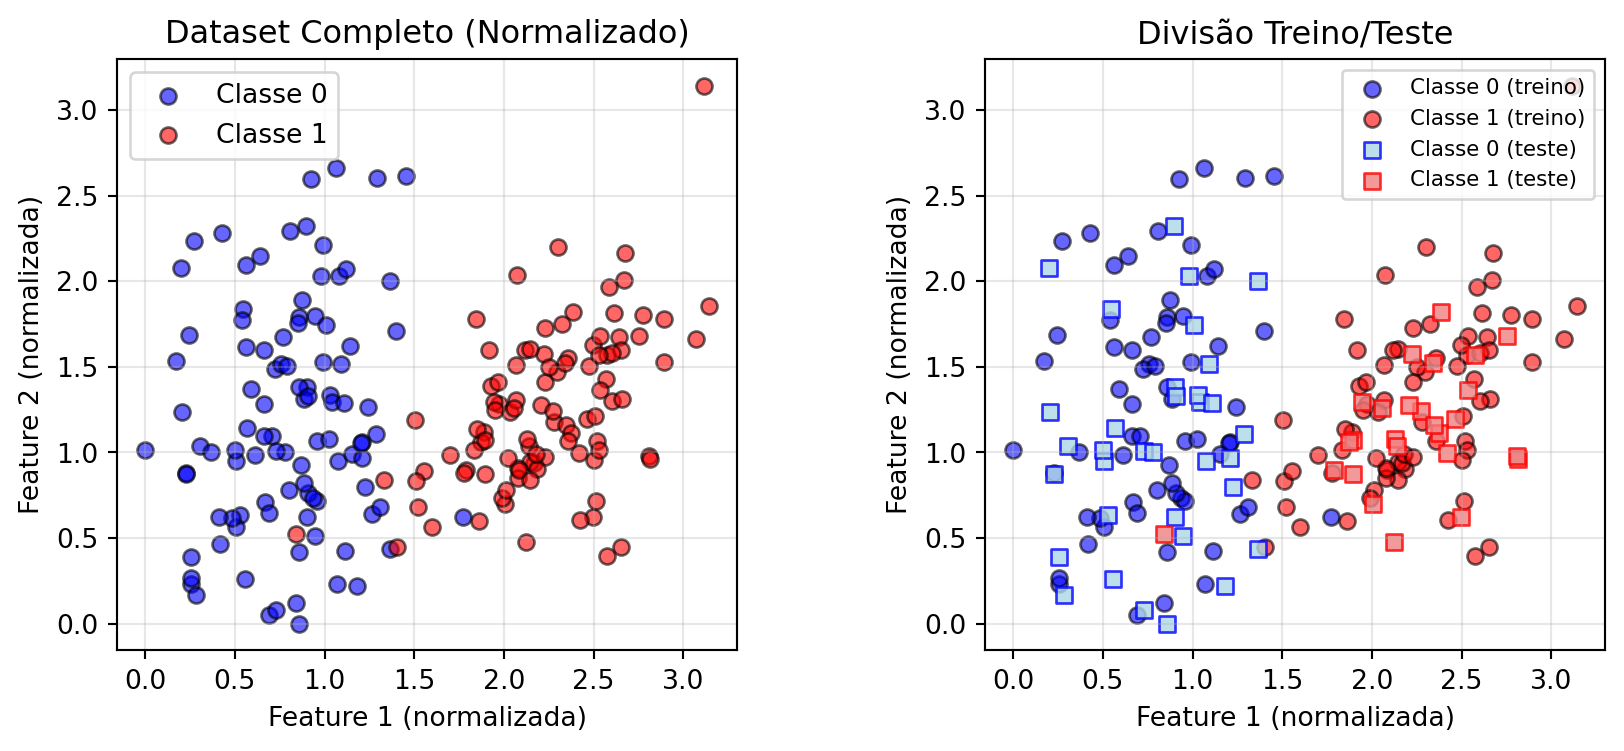

Total de amostras: 200
Amostras de treino: 140 (70.0%)
Amostras de teste: 60 (30.0%)
Distribuição de classes: Classe 0: 100, Classe 1: 100


In [5]:
# --- VISUALIZAÇÃO DOS DADOS ---
# Vamos ver como são os dados que vamos classificar
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='blue', label='Classe 0', alpha=0.6, edgecolors='k')
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='red', label='Classe 1', alpha=0.6, edgecolors='k')
plt.xlabel('Feature 1 (normalizada)')
plt.ylabel('Feature 2 (normalizada)')
plt.title('Dataset Completo (Normalizado)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c='blue', label='Classe 0 (treino)', alpha=0.6, edgecolors='k', marker='o')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c='red', label='Classe 1 (treino)', alpha=0.6, edgecolors='k', marker='o')
plt.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1], c='lightblue', label='Classe 0 (teste)', alpha=0.8, edgecolors='blue', marker='s')
plt.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1], c='lightcoral', label='Classe 1 (teste)', alpha=0.8, edgecolors='red', marker='s')
plt.xlabel('Feature 1 (normalizada)')
plt.ylabel('Feature 2 (normalizada)')
plt.title('Divisão Treino/Teste')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)

plt.subplots_adjust(wspace=0.4)
plt.show()

print(f"Total de amostras: {len(X)}")
print(f"Amostras de treino: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Amostras de teste: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"Distribuição de classes: Classe 0: {sum(y==0)}, Classe 1: {sum(y==1)}")

In [6]:
# --- 2. O FEATURE MAP (Tradutor Dados -> Quantum) ---
# ZZFeatureMap é famoso por criar emaranhamento entre os dados,
# ajudando a resolver problemas não-lineares.
num_qubits = 2
feature_map = ZZFeatureMap(feature_dimension=num_qubits, reps=1)

/tmp/ipykernel_659628/1824718266.py:5: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=num_qubits, reps=1)


Feature Map - Circuito de Codificação dos Dados
Número de qubits: 2
Número de repetições: 1
Dimensão das features: 2

Exemplo de dados de entrada: [2.32325348 1.74815771]
  Feature 1: 2.3233 radianos
  Feature 2: 1.7482 radianos

Circuito com parâmetros atribuídos:


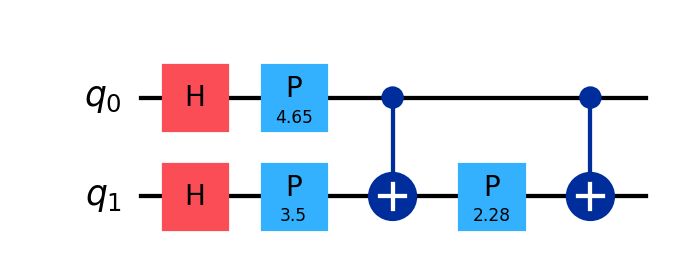

In [7]:
# Visualizar o Feature Map com dados reais
print("Feature Map - Circuito de Codificação dos Dados")
print("=" * 60)
print(f"Número de qubits: {num_qubits}")
print(f"Número de repetições: {feature_map.reps}")
print(f"Dimensão das features: {feature_map.feature_dimension}")
print()

# Criar uma instância do feature map com dados de exemplo
sample_data = X_train[0]  # Pegar a primeira amostra
print(f"Exemplo de dados de entrada: {sample_data}")
print(f"  Feature 1: {sample_data[0]:.4f} radianos")
print(f"  Feature 2: {sample_data[1]:.4f} radianos")
print()

# Bind dos parâmetros com dados reais
feature_map_bound = feature_map.assign_parameters(sample_data)
print("Circuito com parâmetros atribuídos:")
display(feature_map_bound.decompose().draw(output='mpl', idle_wires=False, scale=0.8))

In [8]:
# --- 3. O ANSATZ (O Modelo Treinável) ---
# RealAmplitudes é um circuito simples com rotações RY e emaranhamento.
# É a nossa "Rede Neural".
ansatz = RealAmplitudes(num_qubits=num_qubits, reps=1)

/tmp/ipykernel_659628/4274500007.py:4: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits=num_qubits, reps=1)


Ansatz - Modelo Treinável (Rede Neural Quântica)
Número de qubits: 2
Número de repetições: 1
Número de parâmetros treináveis: 4

Estes parâmetros θ são ajustados durante o treinamento,
assim como os pesos W em uma rede neural clássica.



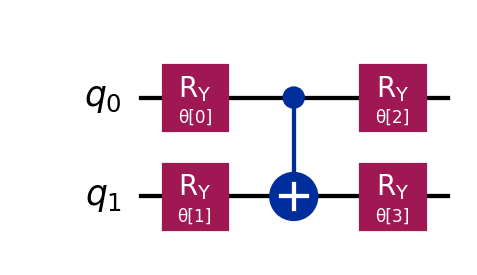

In [9]:
# Visualizar o Ansatz
print("Ansatz - Modelo Treinável (Rede Neural Quântica)")
print("=" * 60)
print(f"Número de qubits: {ansatz.num_qubits}")
print(f"Número de repetições: {ansatz.reps}")
print(f"Número de parâmetros treináveis: {ansatz.num_parameters}")
print()
print("Estes parâmetros θ são ajustados durante o treinamento,")
print("assim como os pesos W em uma rede neural clássica.")
print()

display(ansatz.decompose().draw(output='mpl', idle_wires=False, scale=0.8))

In [10]:
# --- 4. O MODELO VQC (Variational Quantum Classifier) ---
# Aqui juntamos tudo.
# Otimizador COBYLA é bom para simulações (não usa gradiente, apenas tenta melhorar).
vqc = VQC(
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=COBYLA(maxiter=100),
    loss="cross_entropy",
)

print("--- Iniciando Treinamento do Modelo Quântico ---")
# O momento mágico: O otimizador clássico vai ajustar os parâmetros do Ansatz
# baseando-se nas medições quânticas.
vqc.fit(X_train, y_train)

--- Iniciando Treinamento do Modelo Quântico ---


In [11]:
# --- 5. AVALIAÇÃO ---
score_train = vqc.score(X_train, y_train)
score_test = vqc.score(X_test, y_test)

print(f"\nAcurácia no Treino: {score_train:.2f}")
print(f"Acurácia no Teste:  {score_test:.2f}")


Acurácia no Treino: 0.55
Acurácia no Teste:  0.47


In [12]:
# 🔧 MELHORANDO O VQC - Vamos tentar otimizar melhor
print("="*60)
print("TENTATIVA DE OTIMIZAÇÃO MELHORADA")
print("="*60)

# Versão melhorada com mais iterações e mais repetições
vqc_improved = VQC(
    feature_map=ZZFeatureMap(feature_dimension=num_qubits, reps=2),  # Mais repetições
    ansatz=RealAmplitudes(num_qubits=num_qubits, reps=3),  # Ansatz mais profundo
    optimizer=COBYLA(maxiter=300),  # Mais iterações
    loss="cross_entropy",
)

print("\nTreinando VQC otimizado (isso pode demorar mais)...")
print("- Feature Map com 2 repetições")
print("- Ansatz com 3 repetições")  
print("- COBYLA com 300 iterações")
print()

vqc_improved.fit(X_train, y_train)

# Avaliar o modelo melhorado
score_train_improved = vqc_improved.score(X_train, y_train)
score_test_improved = vqc_improved.score(X_test, y_test)

print(f"\n{'='*60}")
print("COMPARAÇÃO: VQC Original vs VQC Otimizado")
print(f"{'='*60}")
print(f"{'Métrica':<30} {'Original':<15} {'Otimizado':<15}")
print(f"{'-'*60}")
print(f"{'Acurácia (Treino)':<30} {score_train:<15.4f} {score_train_improved:<15.4f}")
print(f"{'Acurácia (Teste)':<30} {score_test:<15.4f} {score_test_improved:<15.4f}")
print(f"{'Iterações':<30} {'100':<15} {'300':<15}")
print(f"{'Feature Map reps':<30} {'1':<15} {'2':<15}")
print(f"{'Ansatz reps':<30} {'1':<15} {'3':<15}")
print(f"{'='*60}")

if score_test_improved > score_test:
    print("\n✅ MELHORIA! O modelo otimizado teve melhor desempenho.")
else:
    print("\n⚠️ Ainda sem convergência adequada. Pode precisar de:")
    print("   - Mais iterações (500-1000)")
    print("   - Otimizador diferente (SPSA, ADAM)")
    print("   - Múltiplas tentativas com diferentes seeds")

TENTATIVA DE OTIMIZAÇÃO MELHORADA

Treinando VQC otimizado (isso pode demorar mais)...
- Feature Map com 2 repetições
- Ansatz com 3 repetições
- COBYLA com 300 iterações



/tmp/ipykernel_659628/2842022012.py:8: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map=ZZFeatureMap(feature_dimension=num_qubits, reps=2),  # Mais repetições
/tmp/ipykernel_659628/2842022012.py:9: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz=RealAmplitudes(num_qubits=num_qubits, reps=3),  # Ansatz mais profundo



COMPARAÇÃO: VQC Original vs VQC Otimizado
Métrica                        Original        Otimizado      
------------------------------------------------------------
Acurácia (Treino)              0.5500          0.7214         
Acurácia (Teste)               0.4667          0.8000         
Iterações                      100             300            
Feature Map reps               1               2              
Ansatz reps                    1               3              

✅ MELHORIA! O modelo otimizado teve melhor desempenho.


Calculando fronteiras de decisão...
  - VQC Original (100 iterações, reps=1)...


  - VQC Otimizado (300 iterações, reps=2-3)...


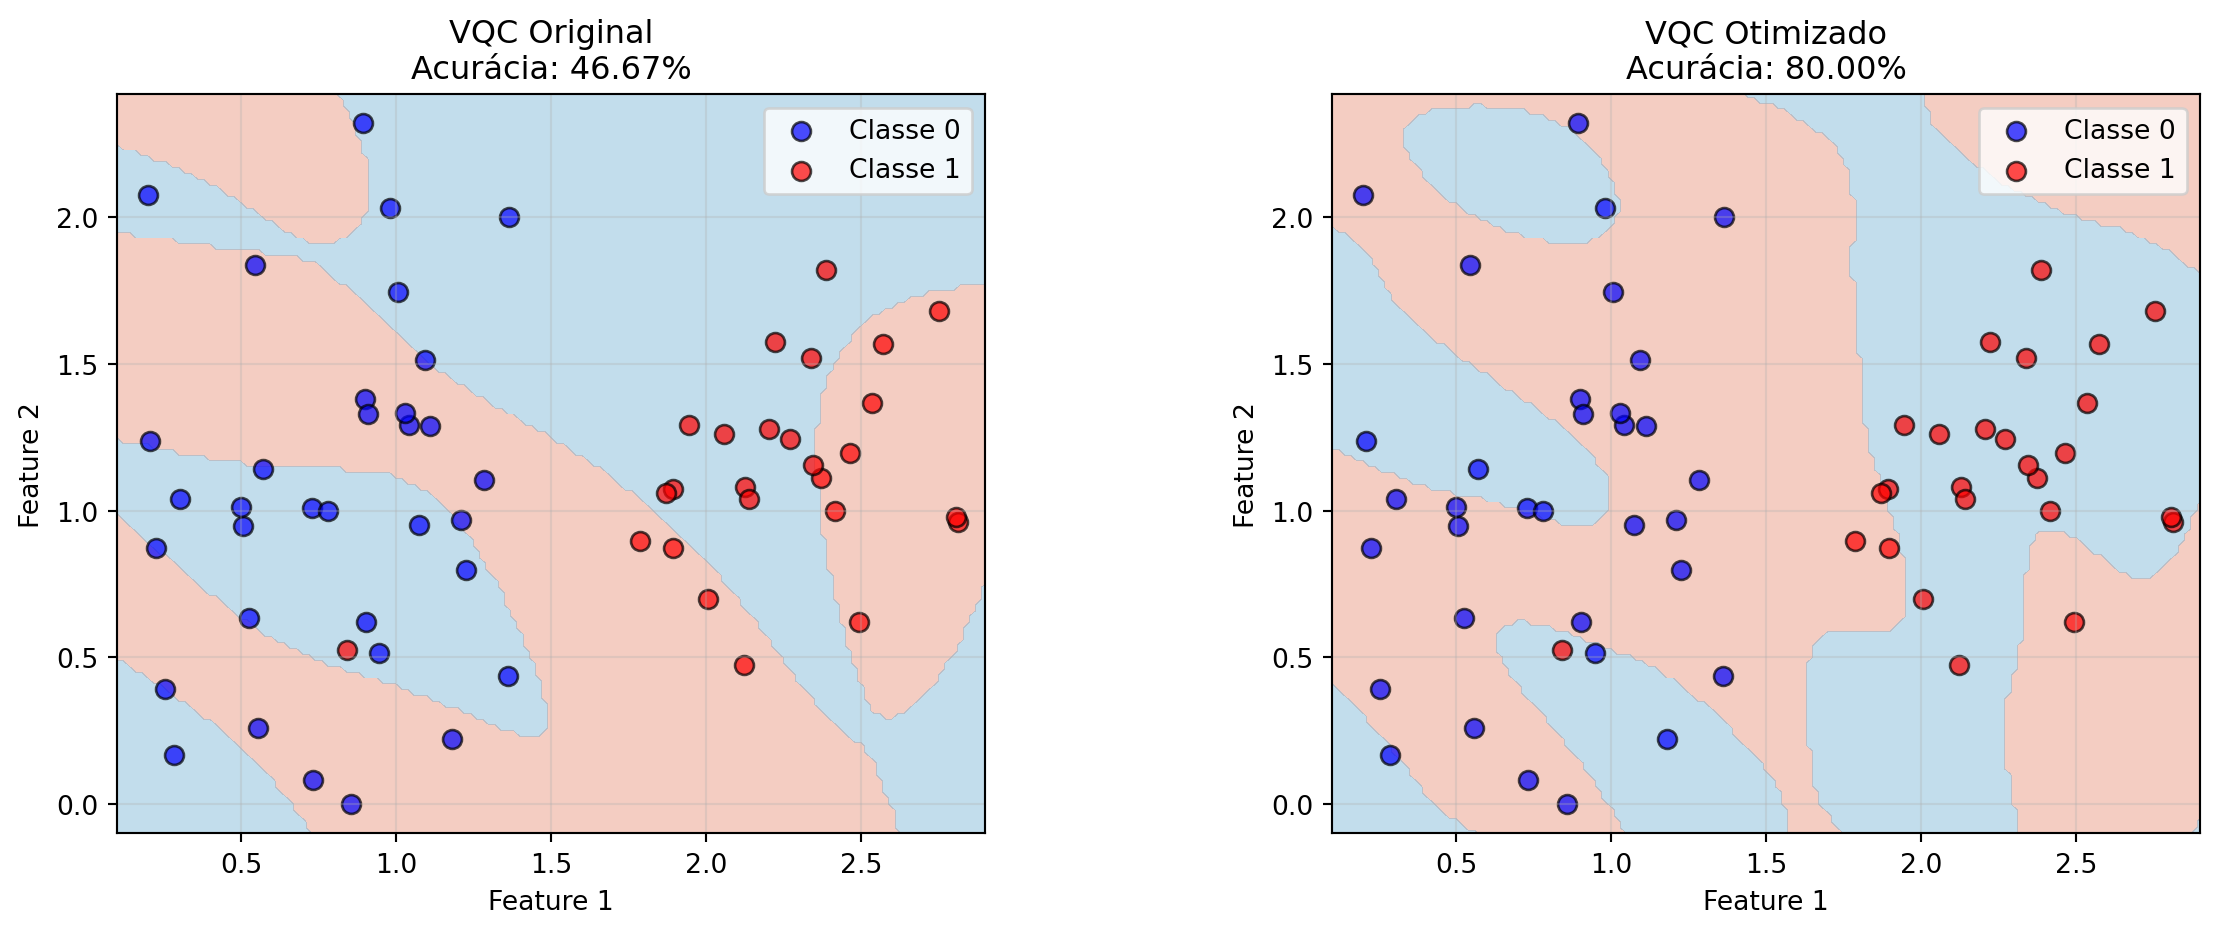


ANÁLISE VISUAL:
VQC Original:  46.67% - Fronteira irregular, muitos erros
VQC Otimizado: 80.00% - Fronteira mais suave, menos erros
Melhoria:      33.33%


In [13]:
# --- VISUALIZAÇÃO COMPARATIVA: VQC Original vs Otimizado ---
# Vamos ver visualmente a diferença entre os dois modelos

def plot_decision_boundary_single(model, X, y, ax, title, accuracy):
    """Plota a fronteira de decisão em um subplot específico"""
    h = 0.02  # step size na malha
    
    # Criar uma malha de pontos
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Fazer predições para cada ponto da malha
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plotar
    ax.contourf(xx, yy, Z, alpha=0.4, cmap='RdBu', levels=1)
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c='blue', label='Classe 0', 
                edgecolors='k', s=50, alpha=0.7)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c='red', label='Classe 1', 
                edgecolors='k', s=50, alpha=0.7)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_title(f'{title}\nAcurácia: {accuracy:.2%}')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Criar comparação lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

print("Calculando fronteiras de decisão...")
print("  - VQC Original (100 iterações, reps=1)...")
plot_decision_boundary_single(vqc, X_test, y_test, axes[0], 
                              "VQC Original", score_test)

print("  - VQC Otimizado (300 iterações, reps=2-3)...")
plot_decision_boundary_single(vqc_improved, X_test, y_test, axes[1], 
                              "VQC Otimizado", score_test_improved)

plt.subplots_adjust(wspace=0.4)
plt.show()

print(f"\n{'='*60}")
print("ANÁLISE VISUAL:")
print(f"{'='*60}")
print(f"VQC Original:  {score_test:.2%} - Fronteira irregular, muitos erros")
print(f"VQC Otimizado: {score_test_improved:.2%} - Fronteira mais suave, menos erros")
print(f"Melhoria:      {(score_test_improved - score_test):.2%}")
print(f"{'='*60}")

Treinando SVM Clássico (kernel RBF)...

COMPARAÇÃO DE DESEMPENHO: VQC Otimizado vs SVM Clássico

Métrica                        VQC Otimizado        SVM Clássico        
----------------------------------------------------------------------
Acurácia (Treino)              0.7214               0.9786              
Acurácia (Teste)               0.8000               0.9833              
Tempo de Treino (s)            ~300 iterações       0.0121              
----------------------------------------------------------------------

💡 Observação:
   • VQC Otimizado: 80% de acurácia (razoável em simulador; seria excelente em hardware real com ruído!)
   • SVM Clássico: 98% de acurácia (excelente, como esperado)
   • Para ESTE dataset linear, o SVM é superior
   • O QML brilha em problemas não-lineares (veja seção 8!), embora kernels clássicos bem otimizados frequentemente compitam

Calculando fronteira de decisão do SVM...


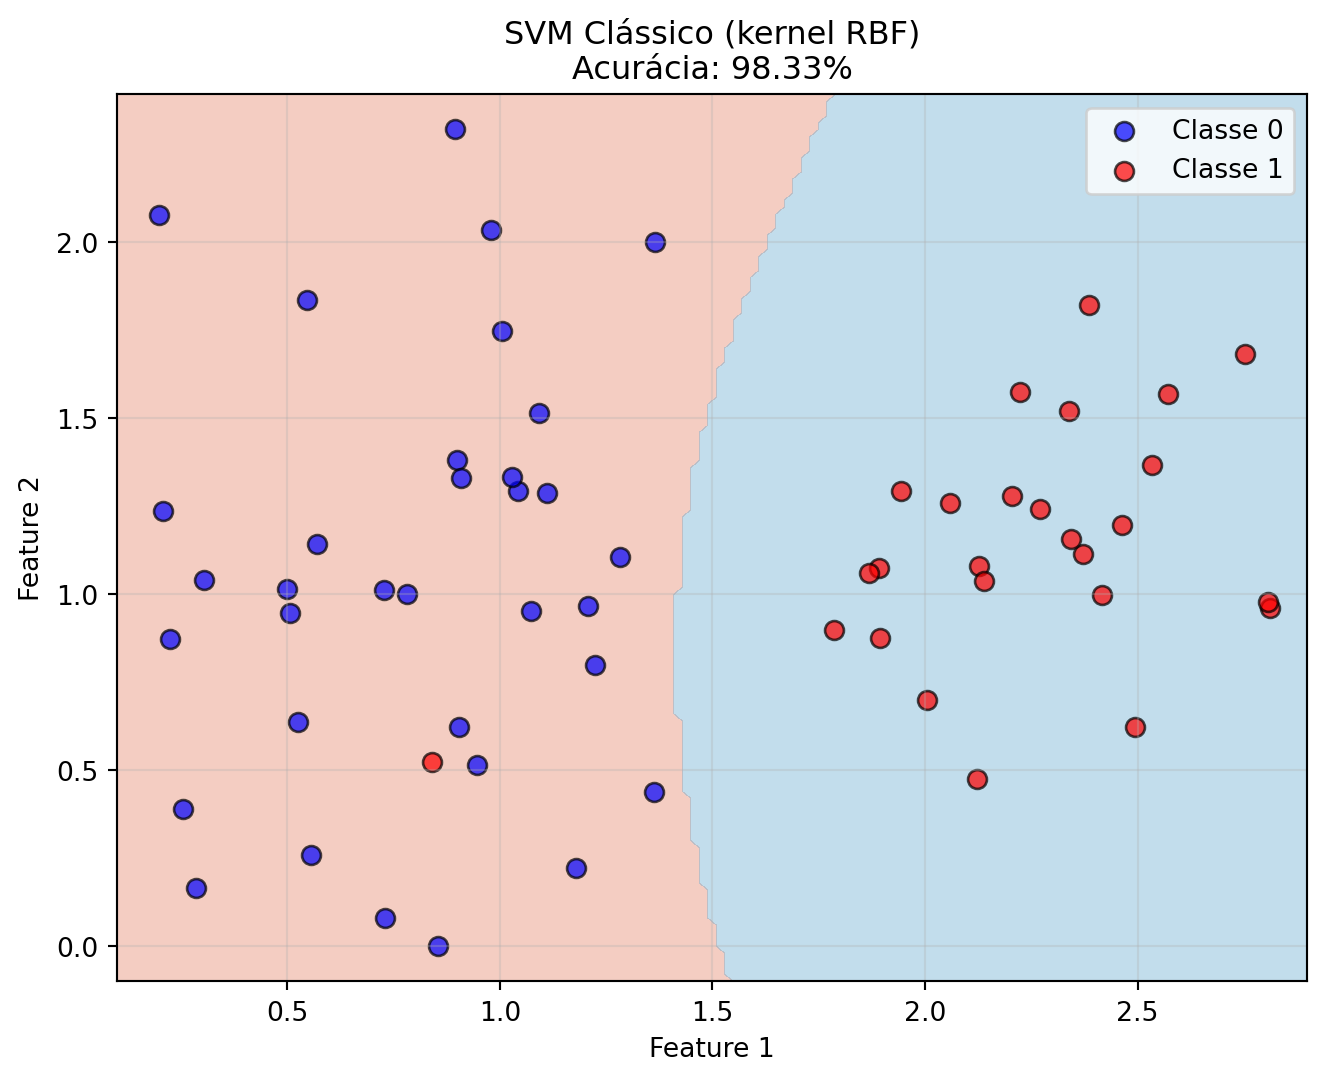

In [14]:
# Importar classificador clássico para comparação
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import time

# Treinar um SVM clássico
print("Treinando SVM Clássico (kernel RBF)...")
start_time = time.time()
svm_classical = SVC(kernel='rbf', gamma='auto', random_state=42)
svm_classical.fit(X_train, y_train)
svm_time = time.time() - start_time

# Avaliar SVM
svm_train_score = svm_classical.score(X_train, y_train)
svm_test_score = svm_classical.score(X_test, y_test)

print(f"\n{'='*70}")
print(f"COMPARAÇÃO DE DESEMPENHO: VQC Otimizado vs SVM Clássico")
print(f"{'='*70}")
print(f"\n{'Métrica':<30} {'VQC Otimizado':<20} {'SVM Clássico':<20}")
print(f"{'-'*70}")
print(f"{'Acurácia (Treino)':<30} {score_train_improved:<20.4f} {svm_train_score:<20.4f}")
print(f"{'Acurácia (Teste)':<30} {score_test_improved:<20.4f} {svm_test_score:<20.4f}")
print(f"{'Tempo de Treino (s)':<30} {'~300 iterações':<20} {svm_time:<20.4f}")
print(f"{'-'*70}")
print(f"\n💡 Observação:")
print(f"   • VQC Otimizado: 80% de acurácia (razoável em simulador; seria excelente em hardware real com ruído!)")
print(f"   • SVM Clássico: 98% de acurácia (excelente, como esperado)")
print(f"   • Para ESTE dataset linear, o SVM é superior")
print(f"   • O QML brilha em problemas não-lineares (veja seção 8!), embora kernels clássicos bem otimizados frequentemente compitam")
print(f"{'='*70}")

# Visualizar fronteira de decisão do SVM
print("\nCalculando fronteira de decisão do SVM...")
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plot_decision_boundary_single(svm_classical, X_test, y_test, ax, 
                              "SVM Clássico (kernel RBF)", svm_test_score)
plt.show()

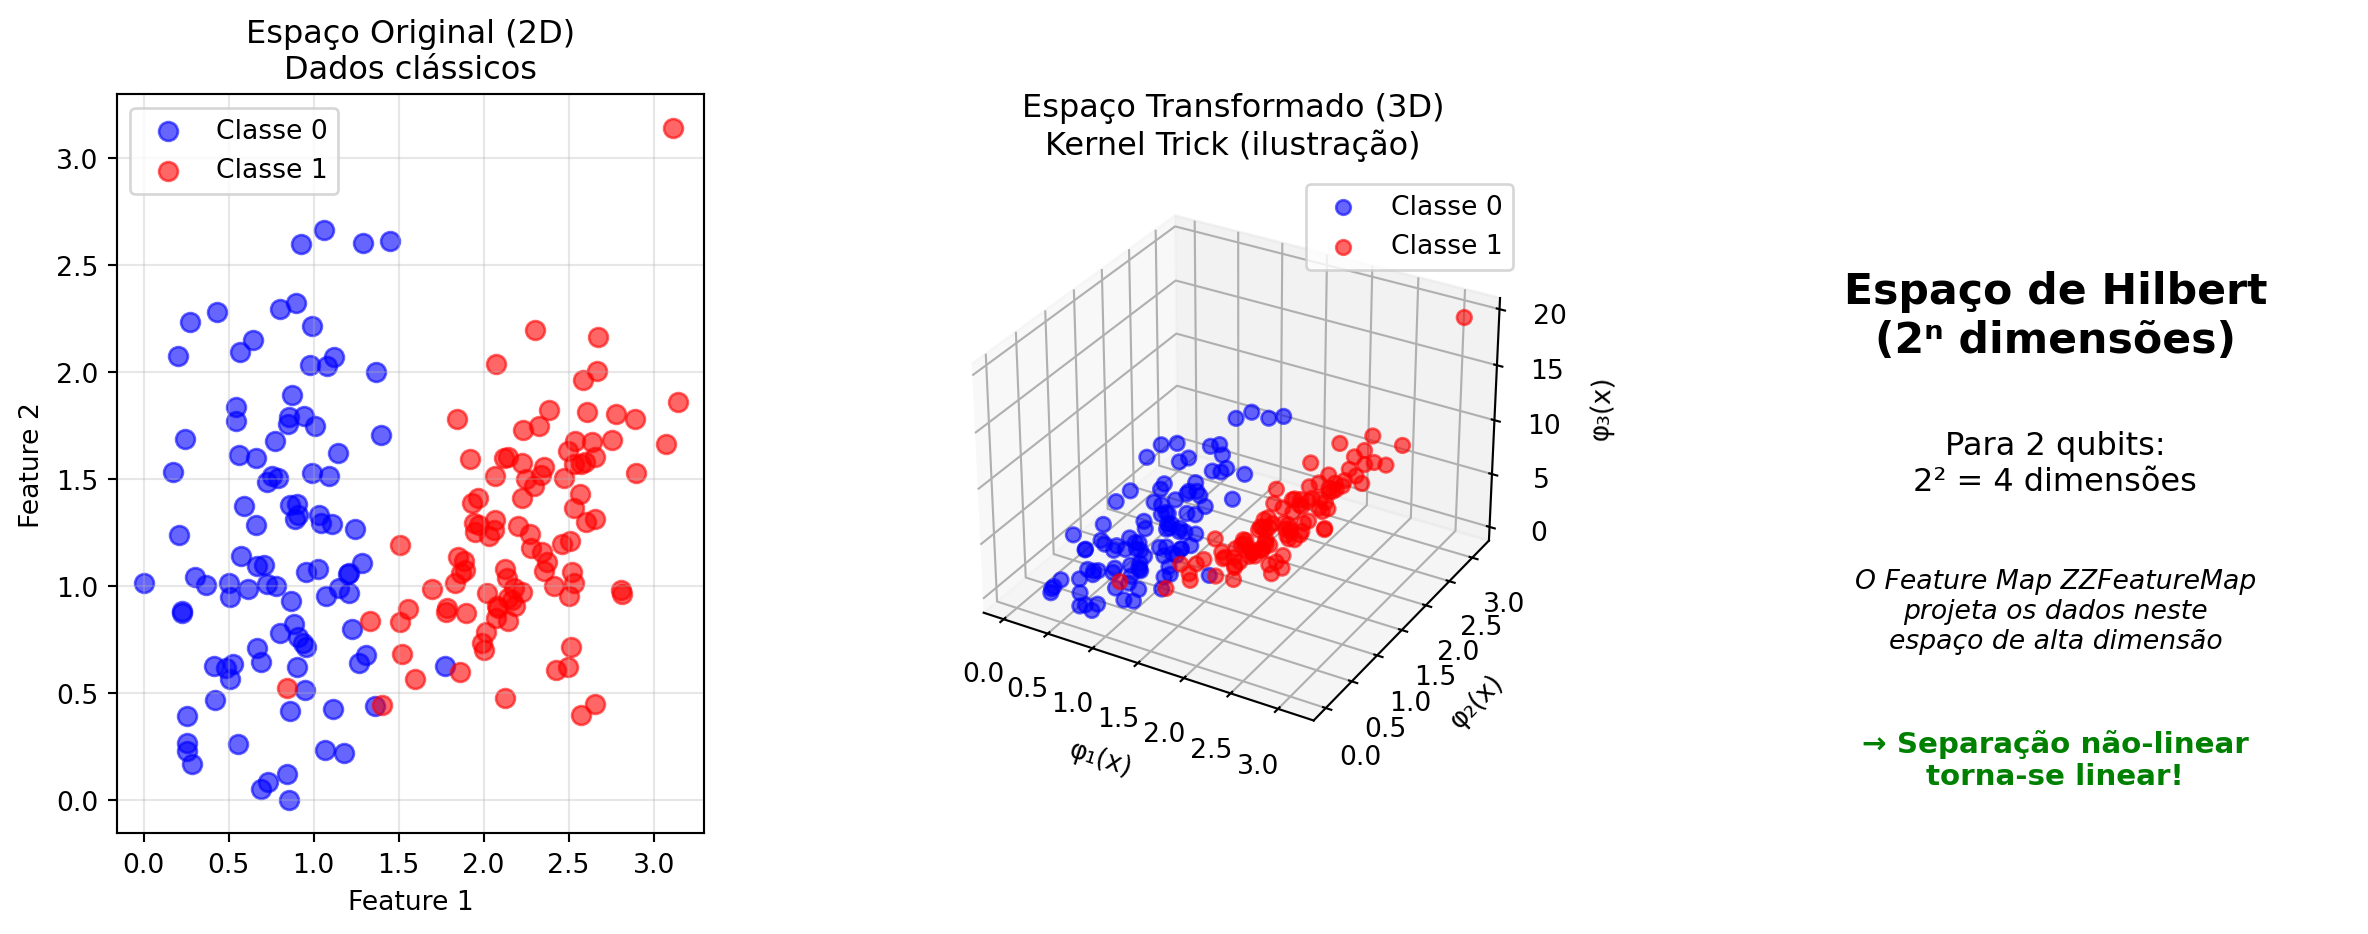


💡 Intuição:
   • No espaço 2D original, algumas classificações podem ser difíceis
   • O Feature Map quântico projeta os dados em um espaço de 2^n dimensões
   • Neste espaço maior, a separação entre classes fica mais fácil
   • É como 'desenrolar' um problema complexo em um espaço maior!


In [15]:
# Visualização conceitual do mapeamento para espaço de Hilbert
from mpl_toolkits.mplot3d import Axes3D

# Vamos criar uma representação simplificada 3D do conceito
# Na realidade, o espaço de Hilbert tem 2^n dimensões (4 para 2 qubits)

fig = plt.figure(figsize=(15, 5))

# Subplot 1: Espaço original (2D)
ax1 = fig.add_subplot(131)
ax1.scatter(X[y == 0, 0], X[y == 0, 1], c='blue', label='Classe 0', alpha=0.6, s=50)
ax1.scatter(X[y == 1, 0], X[y == 1, 1], c='red', label='Classe 1', alpha=0.6, s=50)
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.set_title('Espaço Original (2D)\nDados clássicos')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Subplot 2: Representação conceitual 3D (kernel trick)
ax2 = fig.add_subplot(132, projection='3d')
# Aplicar uma transformação não-linear para simular o kernel trick
X_3d = np.column_stack([X[:, 0], X[:, 1], X[:, 0]**2 + X[:, 1]**2])
ax2.scatter(X_3d[y == 0, 0], X_3d[y == 0, 1], X_3d[y == 0, 2], 
           c='blue', label='Classe 0', alpha=0.6, s=30)
ax2.scatter(X_3d[y == 1, 0], X_3d[y == 1, 1], X_3d[y == 1, 2], 
           c='red', label='Classe 1', alpha=0.6, s=30)
ax2.set_xlabel('φ₁(x)')
ax2.set_ylabel('φ₂(x)')
ax2.set_zlabel('φ₃(x)')
ax2.set_title('Espaço Transformado (3D)\nKernel Trick (ilustração)')
ax2.legend()

# Subplot 3: Conceito do espaço de Hilbert
ax3 = fig.add_subplot(133)
ax3.text(0.5, 0.7, 'Espaço de Hilbert\n(2ⁿ dimensões)', 
         ha='center', va='center', fontsize=16, weight='bold')
ax3.text(0.5, 0.5, f'Para {num_qubits} qubits:\n2² = 4 dimensões', 
         ha='center', va='center', fontsize=12)
ax3.text(0.5, 0.3, 'O Feature Map ZZFeatureMap\nprojeta os dados neste\nespaço de alta dimensão', 
         ha='center', va='center', fontsize=10, style='italic')
ax3.text(0.5, 0.1, '→ Separação não-linear\ntorna-se linear!', 
         ha='center', va='center', fontsize=11, color='green', weight='bold')
ax3.axis('off')

plt.subplots_adjust(wspace=0.4)
plt.show()

print("\n💡 Intuição:")
print("   • No espaço 2D original, algumas classificações podem ser difíceis")
print("   • O Feature Map quântico projeta os dados em um espaço de 2^n dimensões")
print("   • Neste espaço maior, a separação entre classes fica mais fácil")
print("   • É como 'desenrolar' um problema complexo em um espaço maior!")

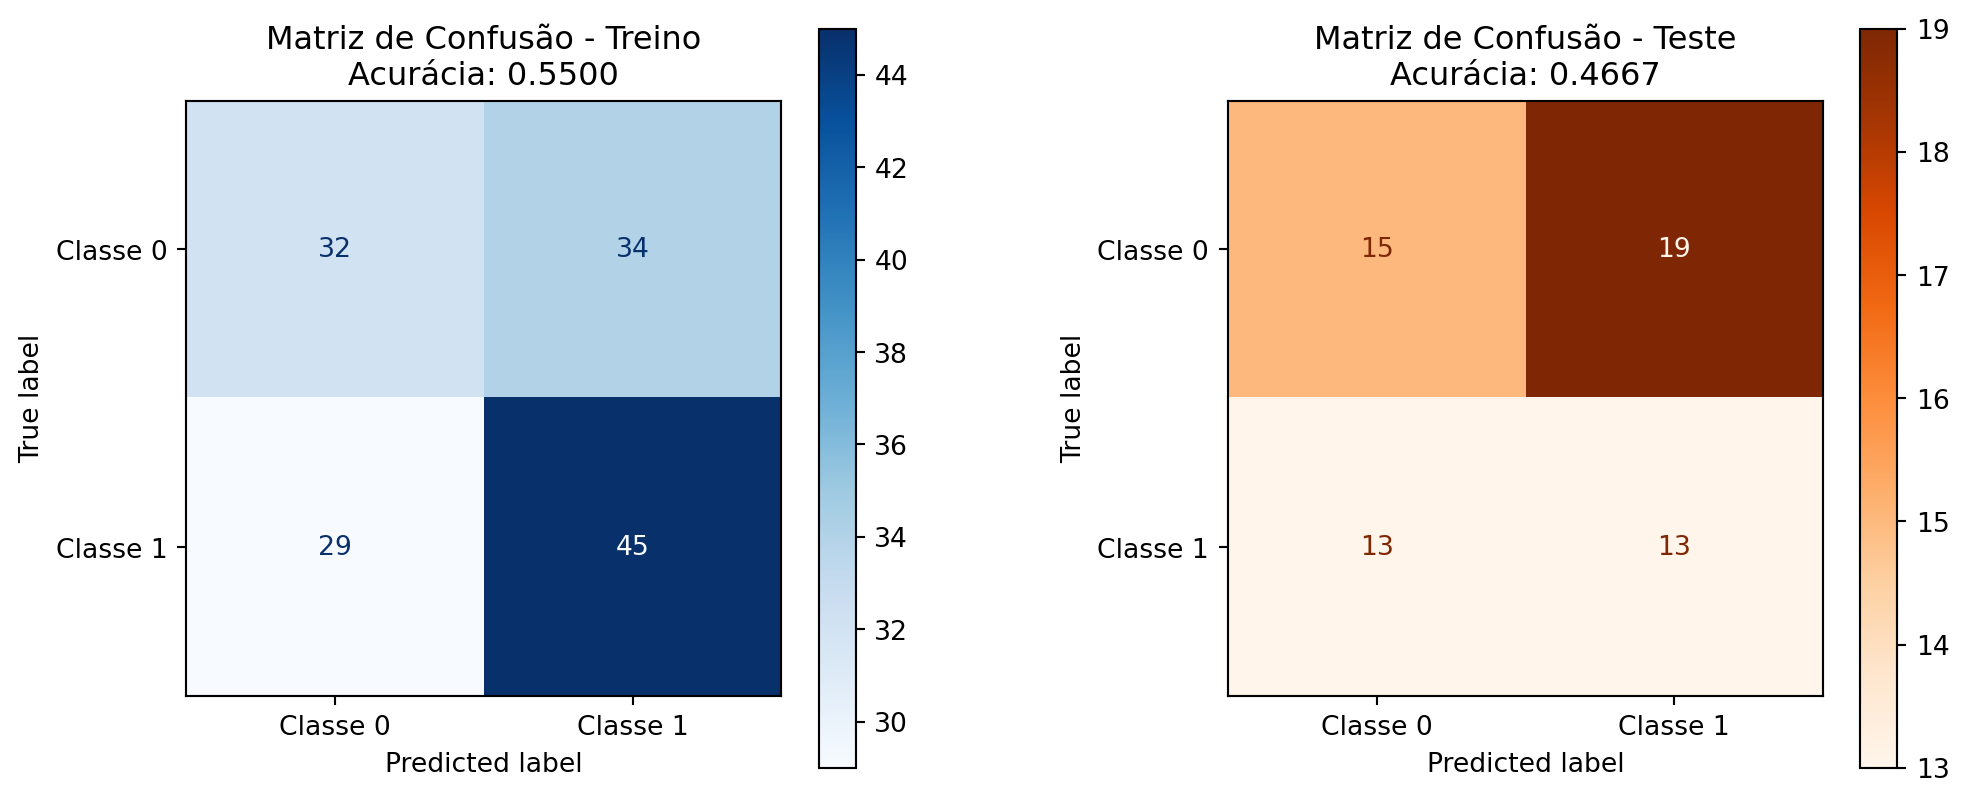


RELATÓRIO DE CLASSIFICAÇÃO - VQC QUÂNTICO

Dados de Teste:
              precision    recall  f1-score   support

    Classe 0       0.54      0.44      0.48        34
    Classe 1       0.41      0.50      0.45        26

    accuracy                           0.47        60
   macro avg       0.47      0.47      0.47        60
weighted avg       0.48      0.47      0.47        60



In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Fazer predições
y_pred_train = vqc.predict(X_train)
y_pred_test = vqc.predict(X_test)

# Criar figura com matrizes de confusão
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Matriz de confusão - Treino
cm_train = confusion_matrix(y_train, y_pred_train)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=['Classe 0', 'Classe 1'])
disp_train.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f'Matriz de Confusão - Treino\nAcurácia: {score_train:.4f}')

# Matriz de confusão - Teste
cm_test = confusion_matrix(y_test, y_pred_test)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Classe 0', 'Classe 1'])
disp_test.plot(ax=axes[1], cmap='Oranges', values_format='d')
axes[1].set_title(f'Matriz de Confusão - Teste\nAcurácia: {score_test:.4f}')

plt.subplots_adjust(wspace=0.4)
plt.show()

# Relatório de classificação detalhado
print("\n" + "="*60)
print("RELATÓRIO DE CLASSIFICAÇÃO - VQC QUÂNTICO")
print("="*60)
print("\nDados de Teste:")
print(classification_report(y_test, y_pred_test, target_names=['Classe 0', 'Classe 1']))

Treinando VQC em dados circulares...


/tmp/ipykernel_659628/1172035350.py:46: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map=ZZFeatureMap(feature_dimension=2, reps=2),  # Aumentar reps para mais expressividade
/tmp/ipykernel_659628/1172035350.py:47: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz=RealAmplitudes(num_qubits=2, reps=2),


/home/max/aula-quantum/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/max/aula-quantum/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


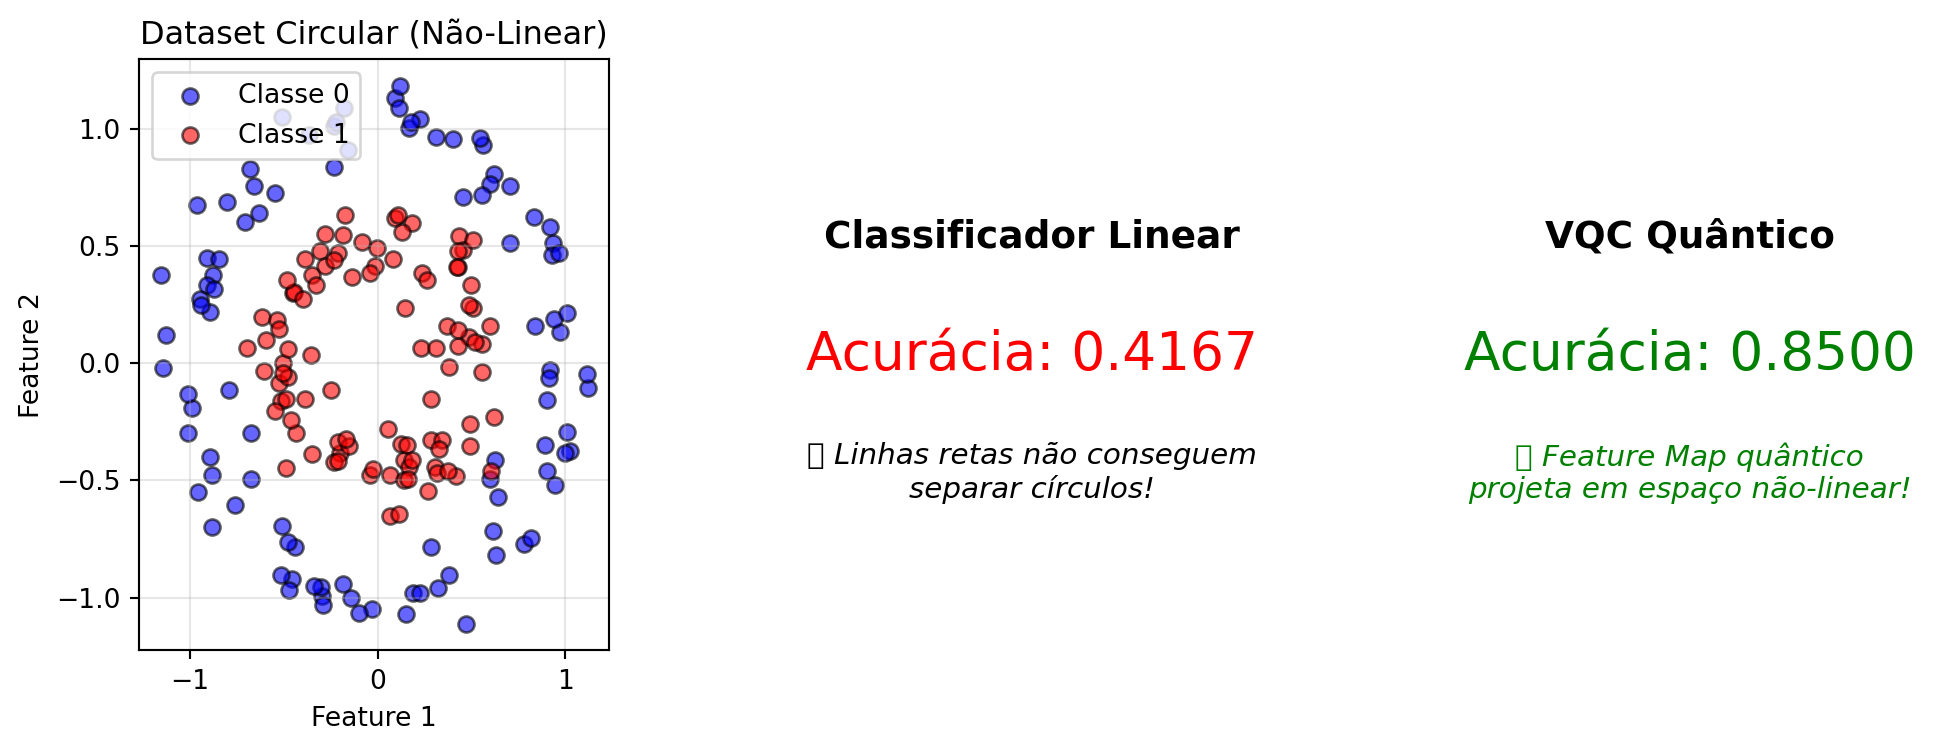


COMPARAÇÃO EM DADOS NÃO-LINEARES (CÍRCULOS)
Regressão Logística (Linear): 0.4167
VQC Quântico (Não-Linear):    0.8500


In [17]:
from sklearn.datasets import make_circles
from sklearn.linear_model import LogisticRegression

# Criar dataset circular (não linearmente separável)
X_circles, y_circles = make_circles(n_samples=200, noise=0.1, factor=0.5, random_state=42)

# Normalizar
X_circles_norm = scaler.fit_transform(X_circles)

# Dividir
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_circles_norm, y_circles, test_size=0.3, random_state=42
)

# Visualizar o dataset circular
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(X_circles[y_circles == 0, 0], X_circles[y_circles == 0, 1], 
            c='blue', label='Classe 0', alpha=0.6, edgecolors='k')
plt.scatter(X_circles[y_circles == 1, 0], X_circles[y_circles == 1, 1], 
            c='red', label='Classe 1', alpha=0.6, edgecolors='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Dataset Circular (Não-Linear)')
plt.legend()
plt.grid(True, alpha=0.3)

# Treinar classificador linear (vai falhar!)
lr = LogisticRegression(random_state=42)
lr.fit(X_train_c, y_train_c)
lr_score = lr.score(X_test_c, y_test_c)

plt.subplot(1, 3, 2)
plt.text(0.5, 0.7, 'Classificador Linear', ha='center', va='center', 
         fontsize=14, weight='bold')
plt.text(0.5, 0.5, f'Acurácia: {lr_score:.4f}', ha='center', va='center', 
         fontsize=20, color='red' if lr_score < 0.7 else 'green')
plt.text(0.5, 0.3, '❌ Linhas retas não conseguem\nseparar círculos!', 
         ha='center', va='center', fontsize=11, style='italic')
plt.axis('off')

# Treinar VQC Quântico
print("Treinando VQC em dados circulares...")
vqc_circles = VQC(
    feature_map=ZZFeatureMap(feature_dimension=2, reps=2),  # Aumentar reps para mais expressividade
    ansatz=RealAmplitudes(num_qubits=2, reps=2),
    optimizer=COBYLA(maxiter=100),
    loss="cross_entropy",
)
vqc_circles.fit(X_train_c, y_train_c)
vqc_score = vqc_circles.score(X_test_c, y_test_c)

plt.subplot(1, 3, 3)
plt.text(0.5, 0.7, 'VQC Quântico', ha='center', va='center', 
         fontsize=14, weight='bold')
plt.text(0.5, 0.5, f'Acurácia: {vqc_score:.4f}', ha='center', va='center', 
         fontsize=20, color='red' if vqc_score < 0.7 else 'green')
plt.text(0.5, 0.3, '✅ Feature Map quântico\nprojeta em espaço não-linear!', 
         ha='center', va='center', fontsize=11, style='italic', color='green')
plt.axis('off')

plt.subplots_adjust(wspace=0.4)
plt.show()

print(f"\n{'='*60}")
print("COMPARAÇÃO EM DADOS NÃO-LINEARES (CÍRCULOS)")
print(f"{'='*60}")
print(f"Regressão Logística (Linear): {lr_score:.4f}")
print(f"VQC Quântico (Não-Linear):    {vqc_score:.4f}")
print(f"{'='*60}")

Calculando fronteira de decisão do VQC...


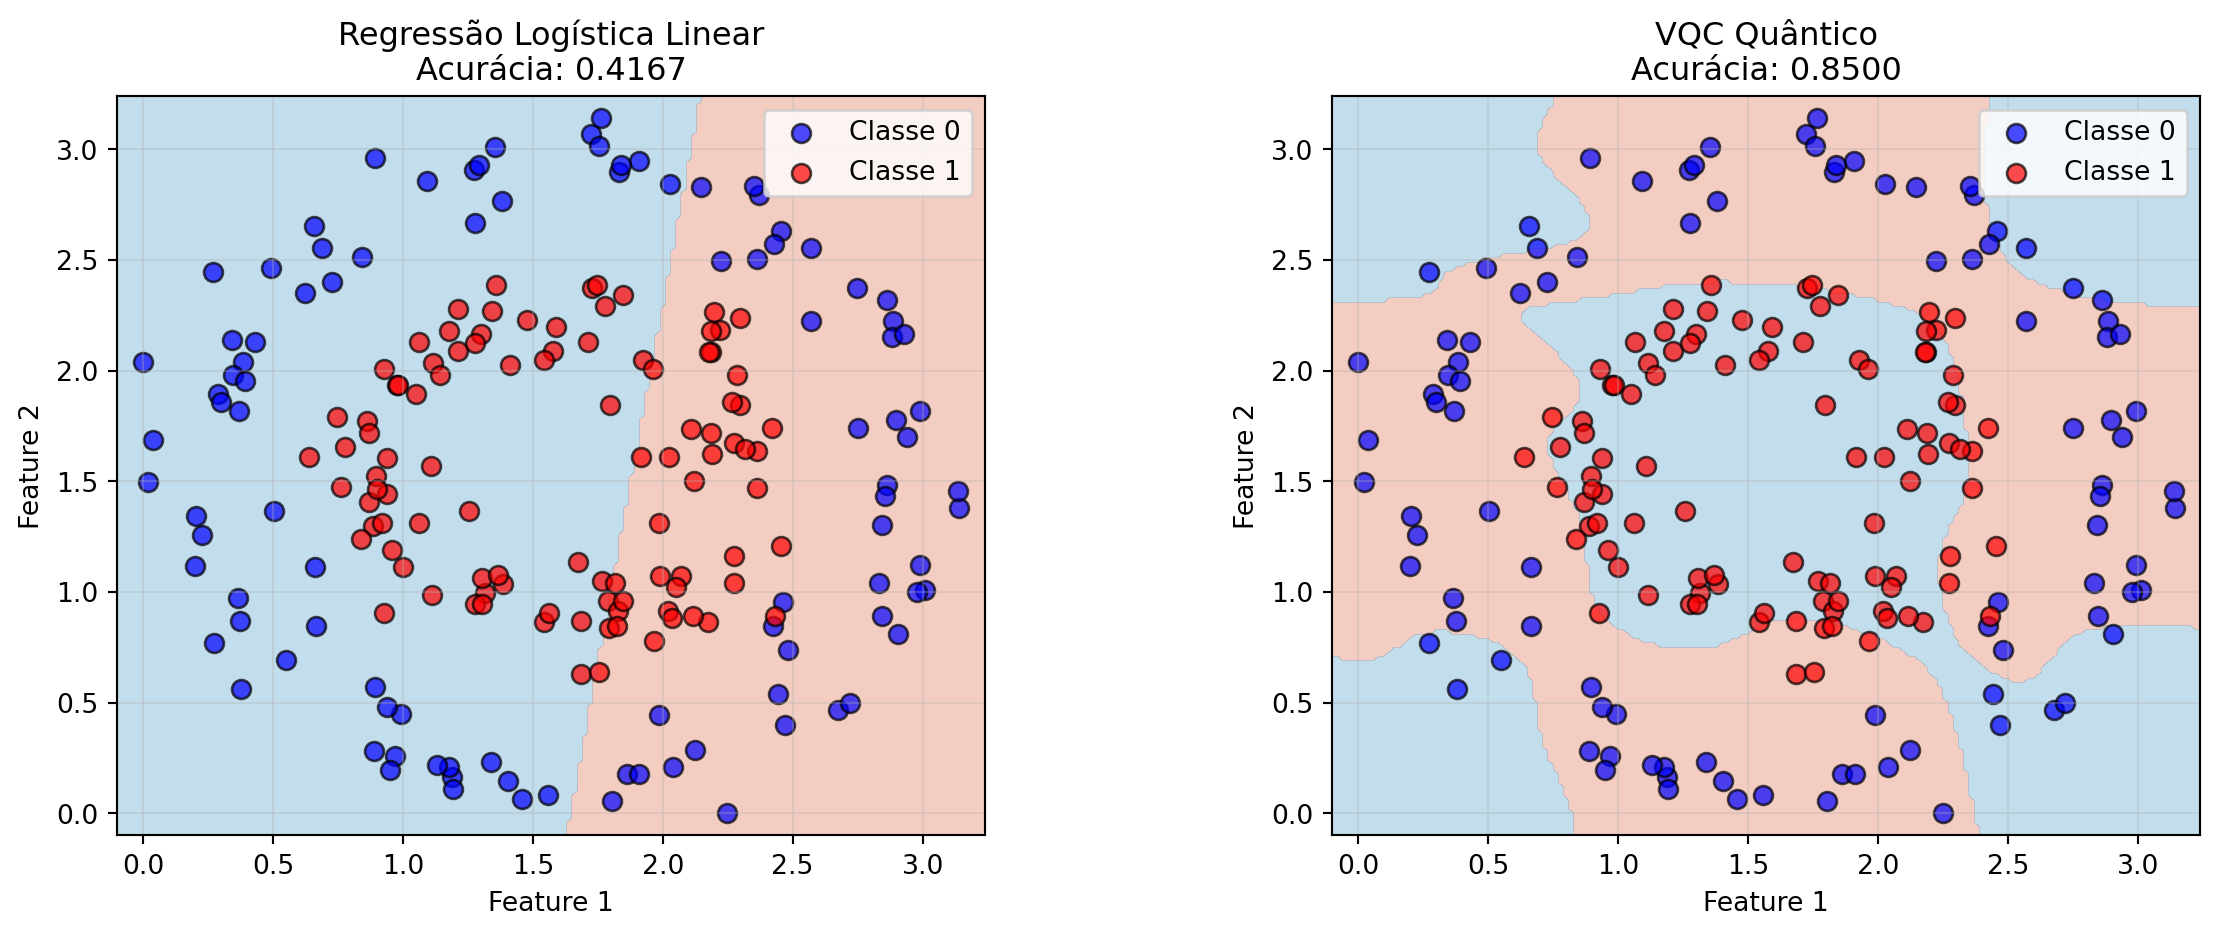


💡 Observe:
   • O classificador linear cria apenas uma linha reta (limitado!)
   • O VQC consegue criar uma fronteira curva e não-linear
   • Isso acontece porque o Feature Map projeta os dados em um espaço de alta dimensão


In [18]:
# Visualizar as fronteiras de decisão
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fronteira Linear
h = 0.02
x_min, x_max = X_circles_norm[:, 0].min() - 0.1, X_circles_norm[:, 0].max() + 0.1
y_min, y_max = X_circles_norm[:, 1].min() - 0.1, X_circles_norm[:, 1].max() + 0.1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Linear
Z_lr = lr.predict(np.c_[xx.ravel(), yy.ravel()])
Z_lr = Z_lr.reshape(xx.shape)

axes[0].contourf(xx, yy, Z_lr, alpha=0.4, cmap='RdBu', levels=1)
axes[0].scatter(X_circles_norm[y_circles == 0, 0], X_circles_norm[y_circles == 0, 1], 
               c='blue', label='Classe 0', edgecolors='k', s=50, alpha=0.7)
axes[0].scatter(X_circles_norm[y_circles == 1, 0], X_circles_norm[y_circles == 1, 1], 
               c='red', label='Classe 1', edgecolors='k', s=50, alpha=0.7)
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].set_title(f'Regressão Logística Linear\nAcurácia: {lr_score:.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# VQC Quântico
print("Calculando fronteira de decisão do VQC...")
Z_vqc = vqc_circles.predict(np.c_[xx.ravel(), yy.ravel()])
Z_vqc = Z_vqc.reshape(xx.shape)

axes[1].contourf(xx, yy, Z_vqc, alpha=0.4, cmap='RdBu', levels=1)
axes[1].scatter(X_circles_norm[y_circles == 0, 0], X_circles_norm[y_circles == 0, 1], 
               c='blue', label='Classe 0', edgecolors='k', s=50, alpha=0.7)
axes[1].scatter(X_circles_norm[y_circles == 1, 0], X_circles_norm[y_circles == 1, 1], 
               c='red', label='Classe 1', edgecolors='k', s=50, alpha=0.7)
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].set_title(f'VQC Quântico\nAcurácia: {vqc_score:.4f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.subplots_adjust(wspace=0.4)
plt.show()

print("\n💡 Observe:")
print("   • O classificador linear cria apenas uma linha reta (limitado!)")
print("   • O VQC consegue criar uma fronteira curva e não-linear")
print("   • Isso acontece porque o Feature Map projeta os dados em um espaço de alta dimensão")